In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import json


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 64
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)


In [9]:
train_data = train_gen.flow_from_directory(
    r'C:\Users\offic\Desktop\Brain Tumor Dataset\training',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical'
)

val_data = test_gen.flow_from_directory(
    r'C:\Users\offic\Desktop\Brain Tumor Dataset\testing',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical'
)
with open("class_indices.json", "w") as f:
    json.dump(train_data.class_indices, f)

print("Class indices:", train_data.class_indices)

Found 5712 images belonging to 4 classes.
Found 1312 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [10]:
model = Sequential([
    Input(shape=(img_size, img_size, 1)),               
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  
])


In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  
    metrics=['accuracy']
)


In [12]:
history = model.fit(train_data, validation_data=val_data, epochs=10)

C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 51s 269ms/step - accuracy: 0.5770 - loss: 0.9644 - val_accuracy: 0.7713 - val_loss: 0.5604
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - accuracy: 0.8255 - loss: 0.4789 - val_accuracy: 0.8087 - val_loss: 0.4515
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.8571 - loss: 0.3699 - val_accuracy: 0.8293 - val_loss: 0.3968
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.8792 - loss: 0.3185 - val_accuracy: 0.8605 - val_loss: 0.3203
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 160ms/step - accuracy: 0.9073 - loss: 0.2434 - val_accuracy: 0.8796 - val_loss: 0.2731
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 161ms/step - accuracy: 0.9179 - loss: 0.2127 - val_accuracy: 0.9116 - val_loss: 0.2140
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 162ms/step - accuracy: 0.9414 - loss: 0.1715 - val_accuracy: 0.9002 - val_loss: 0.2200
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 29s 164ms/step - accuracy: 0.9394 - loss: 0

In [13]:
model.save("brain_tumor_classifier.keras")

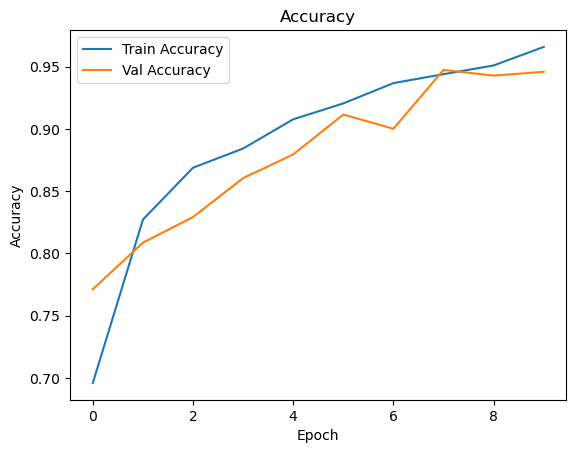

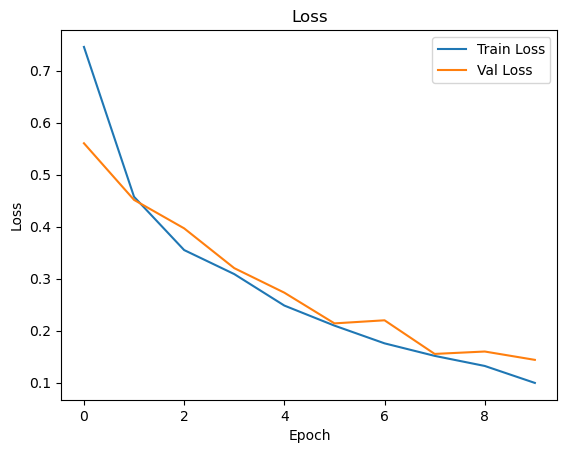

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [15]:
model.save('brain_tumor_classifier.keras')

In [16]:
import cv2
import numpy as np

image_path = r"C:\Users\offic\Desktop\Brain Tumor Dataset\testing\glioma\Te-gl_0017.jpg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (64, 64))
img = img / 255.0
img = img.reshape(1, 64, 64, 1)

prediction = model.predict(img)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
print("Predicted class:", class_names[np.argmax(prediction)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Predicted class: glioma


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


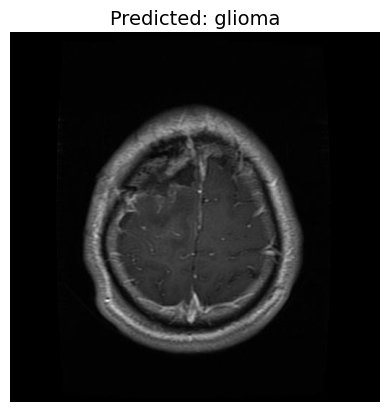

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Desktop\Brain Tumor Dataset\testing\glioma\Te-gl_0017.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (64, 64))
img_normalized = img_resized / 255.0
img_input = img_normalized.reshape(1, 64, 64, 1)

prediction = model.predict(img_input)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_class}", fontsize=14)
plt.axis('off')
plt.show()


In [18]:
import cv2
import numpy as np

image_path = r"C:\Users\offic\Desktop\Brain Tumor Dataset\testing\notumor\Te-no_0016.jpg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (64, 64))
img = img / 255.0
img = img.reshape(1, 64, 64, 1)

prediction = model.predict(img)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
print("Predicted class:", class_names[np.argmax(prediction)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted class: no_tumor


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


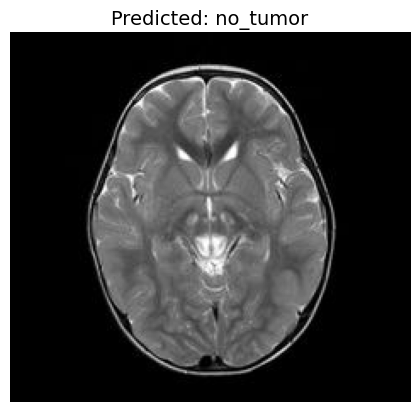

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Desktop\Brain Tumor Dataset\testing\notumor\Te-no_0016.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (64, 64))
img_normalized = img_resized / 255.0
img_input = img_normalized.reshape(1, 64, 64, 1)

prediction = model.predict(img_input)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_class}", fontsize=14)
plt.axis('off')
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


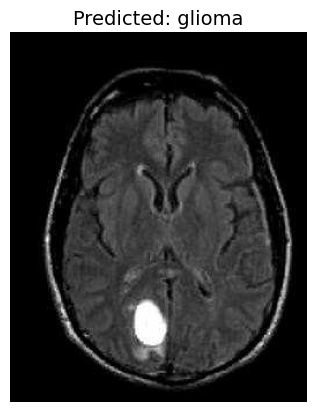

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Downloads\brain.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  

if img is not None:
    img_resized = cv2.resize(img, (64, 64))         

    img_normalized = img_resized / 255.0
    img_input = img_normalized.reshape(1, 64, 64, 1)  

    prediction = model.predict(img_input)
    class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {predicted_class}", fontsize=14)
    plt.axis('off')
    plt.show()

else:
    print("⚠️ Error: Image not found or unreadable!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


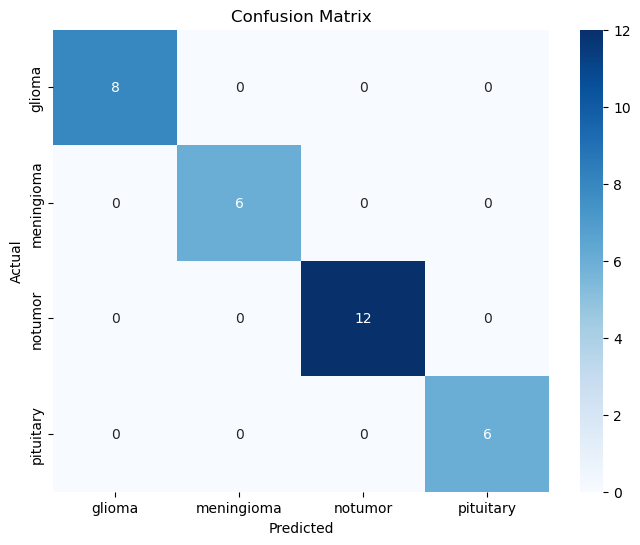

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00         8
  meningioma       1.00      1.00      1.00         6
     notumor       1.00      1.00      1.00        12
   pituitary       1.00      1.00      1.00         6

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

val_images, val_labels = next(val_data)  
y_true = np.argmax(val_labels, axis=1)   

predictions = model.predict(val_images)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=val_data.class_indices,
            yticklabels=val_data.class_indices)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=list(val_data.class_indices.keys()))) 


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Downloads\healthy brain.jpeg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  

if img is not None:
    img_resized = cv2.resize(img, (64, 64))         

    img_normalized = img_resized / 255.0
    img_input = img_normalized.reshape(1, 64, 64, 1)  

    prediction = model.predict(img_input)
    class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {predicted_class}", fontsize=14)
    plt.axis('off')
    plt.show()

else:
    print("⚠️ Error: Image not found or unreadable!")

⚠️ Error: Image not found or unreadable!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


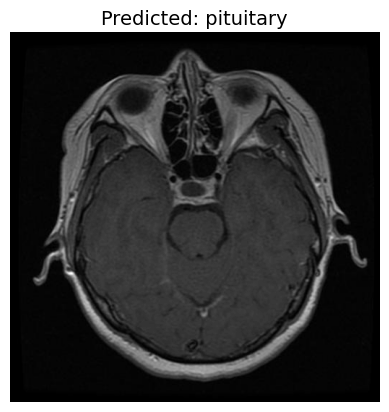

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Desktop\Brain Tumor Dataset\testing\pituitary\Te-pi_0062.jpg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  

if img is not None:
    img_resized = cv2.resize(img, (64, 64))         

    img_normalized = img_resized / 255.0
    img_input = img_normalized.reshape(1, 64, 64, 1)  

    prediction = model.predict(img_input)
    class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {predicted_class}", fontsize=14)
    plt.axis('off')
    plt.show()

else:
    print("⚠️ Error: Image not found or unreadable!")

In [18]:
model.save("brain_tumor_classifier.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


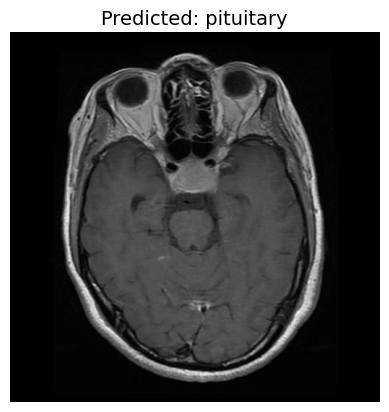

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Desktop\Brain Tumor Dataset\testing\pituitary\Te-pi_0016.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (64, 64))
img_normalized = img_resized / 255.0
img_input = img_normalized.reshape(1, 64, 64, 1)

prediction = model.predict(img_input)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_class}", fontsize=14)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


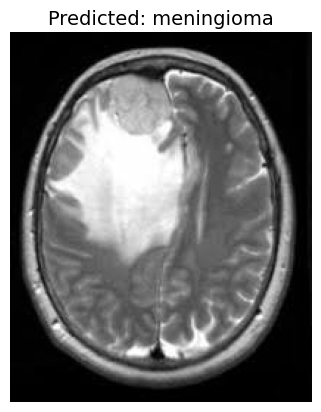

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Desktop\Brain Tumor Dataset\testing\meningioma\Te-me_0036.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (64, 64))
img_normalized = img_resized / 255.0
img_input = img_normalized.reshape(1, 64, 64, 1)

prediction = model.predict(img_input)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_class}", fontsize=14)
plt.axis('off')
plt.show()



In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\offic\Downloads\tech-companies.png"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (64, 64))
img_normalized = img_resized / 255.0
img_input = img_normalized.reshape(1, 64, 64, 1)

prediction = model.predict(img_input)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_class}", fontsize=14)
plt.axis('off')
plt.show()

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'
